In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
from helper_functions import *
from algorithms import *
import random
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

In [ ]:
BASE_DIR = './'
DIR_24   =  "./chromosomes"
IMG_24   =  f"{DIR_24}"
IMG_24 = Path('/Users/aning/Downloads/chromosomes')
SUBSET_SIZE = 100
all_img_24   = sorted(IMG_24.glob("*.jpg"))   + sorted(IMG_24.glob("*.JPG"))  

In [ ]:
img_24   = random.sample(all_img_24,   min(SUBSET_SIZE, len(all_img_24)))   if SUBSET_SIZE else all_img_24

In [ ]:
mask = chromosome_mask_with_active_contour(img_24[5], plot=True)

In [ ]:
mask = chromosome_mask_with_adaptive_histogram(img_24[8],plot=True)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import skimage.io

index = 8
img_gray = skimage.io.imread(img_24[index], as_gray=True)
mask     = chromosome_mask_with_active_contour(img_24[index], plot=False,)

# build overlay
img_rgb  = np.stack([img_gray] * 3, axis=-1)
overlay  = img_rgb.copy()
overlay[mask, 1] = 0.8   # green channel where mask is True

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(img_gray,  cmap='gray')
axes[0].set_title('Original')
axes[1].imshow(mask,      cmap='gray')
axes[1].set_title('Mask')
axes[2].imshow(overlay)
axes[2].set_title('Overlay')

for ax in axes:
    ax.axis('off')
plt.tight_layout()
plt.show()


In [30]:
from algorithms import classify_denver_groups, extract_centromere_and_bands, extract_chromosome_features

abnormal_img = Path('/Users/aning/Downloads/abnormal')
sorted_abnormal_images = sorted(abnormal_img.glob("*.jpg")) + sorted(abnormal_img.glob("*.JPG"))

df_abnormal       = extract_chromosome_features(sorted_abnormal_images, method='adaptive_histogram', plot=False)
df_abnormal       = df_abnormal[df_abnormal['solidity'] > 0.8]

# filter out images with too few detected chromosomes (avoids inflated relative lengths)
min_chrom         = 20
counts            = df_abnormal.groupby('image_name')['chromosome_label'].count()
valid             = counts[counts >= min_chrom].index
df_abnormal       = df_abnormal[df_abnormal['image_name'].isin(valid)]
print(f"Abnormal — images kept: {len(valid)} / {counts.shape[0]}  |  chromosomes: {len(df_abnormal)}")

df_abnormal       = extract_centromere_and_bands(df_abnormal, plot=False)
df_classified_abnormal = classify_denver_groups(df_abnormal)


Abnormal — images kept: 41 / 51  |  chromosomes: 1271


In [31]:
from algorithms import classify_denver_groups, extract_centromere_and_bands, extract_chromosome_features

normal_img = Path('/Users/aning/Downloads/normal')
sorted_normal_images = sorted(normal_img.glob("*.jpg")) + sorted(normal_img.glob("*.JPG"))

df_normal         = extract_chromosome_features(sorted_normal_images[:52], method='adaptive_histogram', plot=False)
df_normal         = df_normal[df_normal['solidity'] > 0.8]

# filter out images with too few detected chromosomes (avoids inflated relative lengths)
min_chrom         = 20
counts            = df_normal.groupby('image_name')['chromosome_label'].count()
valid             = counts[counts >= min_chrom].index
df_normal         = df_normal[df_normal['image_name'].isin(valid)]
print(f"Normal — images kept: {len(valid)} / {counts.shape[0]}  |  chromosomes: {len(df_normal)}")

df_normal         = extract_centromere_and_bands(df_normal, plot=False)
df_classified_normal = classify_denver_groups(df_normal)


Normal — images kept: 51 / 52  |  chromosomes: 1660


In [38]:
print(sorted_normal_images[:52])
print(sorted_abnormal_images)

[PosixPath('/Users/aning/Downloads/normal/103064.jpg'), PosixPath('/Users/aning/Downloads/normal/103095.jpg'), PosixPath('/Users/aning/Downloads/normal/103191.jpg'), PosixPath('/Users/aning/Downloads/normal/1032292.jpg'), PosixPath('/Users/aning/Downloads/normal/104143.jpg'), PosixPath('/Users/aning/Downloads/normal/104601.jpg'), PosixPath('/Users/aning/Downloads/normal/104632.jpg'), PosixPath('/Users/aning/Downloads/normal/104792.jpg'), PosixPath('/Users/aning/Downloads/normal/104801.jpg'), PosixPath('/Users/aning/Downloads/normal/104922.jpg'), PosixPath('/Users/aning/Downloads/normal/1050012.jpg'), PosixPath('/Users/aning/Downloads/normal/1050031.jpg'), PosixPath('/Users/aning/Downloads/normal/1050222_1.jpg'), PosixPath('/Users/aning/Downloads/normal/1050225_1.jpg'), PosixPath('/Users/aning/Downloads/normal/1050282.jpg'), PosixPath('/Users/aning/Downloads/normal/1050302_1.jpg'), PosixPath('/Users/aning/Downloads/normal/1050324.jpg'), PosixPath('/Users/aning/Downloads/normal/1050364.j

## Denver Group Morphometric Summary — Normal vs Abnormal
Ranges of relative length (%), arm ratio, and centromeric index per Denver group,
styled after Table 2 of the Denver Convention (1960).

In [35]:
def denver_summary_table(df, label=''):
    """
    Build a per-Denver-group summary table with ranges of:
      A — relative length (%)
      B — arm ratio (longer / shorter arm)
      C — centromeric index (× 100, to match Denver paper scale)
    """
    GROUPS = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
    rows = []
    for group in GROUPS:
        sub = df[df['denver_group'] == group].dropna(
            subset=['relative_length', 'arm_ratio', 'centromeric_index'])
        if len(sub) == 0:
            rows.append({'Group': group,
                         f'A — Rel. Length {label}': '—',
                         f'B — Arm Ratio {label}':   '—',
                         f'C — CI {label}':           '—'})
            continue

        rl  = sub['relative_length']
        ar  = sub['arm_ratio']
        ci  = sub['centromeric_index'] * 100   # scale to match paper (0–50)

        rows.append({
            'Group':                       group,
            f'A — Rel. Length {label}':   f"{rl.min():.1f}–{rl.max():.1f}",
            f'B — Arm Ratio {label}':     f"{ar.min():.1f}–{ar.max():.1f}",
            f'C — CI {label}':            f"{ci.min():.0f}–{ci.max():.0f}",
        })
    return pd.DataFrame(rows).set_index('Group')


t_normal   = denver_summary_table(df_classified_normal,   'Normal')
t_abnormal = denver_summary_table(df_classified_abnormal, 'Abnormal')

table = pd.concat([t_normal, t_abnormal], axis=1)

# ── styled display ────────────────────────────────────────────────────────────
styled = (table.style
          .set_caption("Table 2 (replicated) — Quantitative characteristics per Denver group. "
                       "A = relative length (%), B = arm ratio, C = centromeric index (×100).")
          .set_table_styles([
              {'selector': 'caption',
               'props': [('font-size', '12px'), ('font-weight', 'bold'),
                         ('text-align', 'left'), ('margin-bottom', '6px')]},
              {'selector': 'th',
               'props': [('background-color', '#f0f0f0'), ('text-align', 'center'),
                         ('border', '1px solid #000'), ('padding', '4px 8px')]},
              {'selector': 'td',
               'props': [('text-align', 'center'), ('border', '1px solid #ddd'),
                         ('padding', '4px 8px')]},
          ])
          .set_properties(**{'font-size': '11px'})
)

display(styled)
table.to_csv('denver_table2.csv')          # CSV for Excel
table.to_excel('denver_table2.xlsx')       # Excel with formatting
table.to_latex('denver_table2.tex')        # LaTeX for papers



,A — Rel. Length Normal,B — Arm Ratio Normal,C — CI Normal,A — Rel. Length Abnormal,B — Arm Ratio Abnormal,C — CI Abnormal
Group,,,,,,
A,3.1–11.1,1.0–3.0,25–50,2.8–11.6,1.0–3.1,24–50
B,3.0–7.2,1.6–3.1,24–38,2.9–7.8,1.6–3.1,24–38
C,1.9–6.3,1.0–3.0,25–50,1.7–6.2,1.0–3.0,25–50
D,1.4–6.1,3.0–3.2,24–25,1.2–6.2,3.0–3.3,23–25
E,1.4–4.0,1.0–3.0,25–50,1.2–3.8,1.0–3.0,25–50
F,1.0–3.0,1.0–3.0,25–50,1.0–2.7,1.0–3.0,25–49
G,0.8–2.7,1.1–3.3,23–49,0.8–2.8,1.1–3.3,23–47


In [36]:
with open('denver_table2.html', 'w') as f:
    f.write(styled.to_html())


## Statistical Comparison — Normal vs Abnormal
### 1. Mann-Whitney U Test (per group, per feature)

In [33]:
from scipy.stats import mannwhitneyu

GROUPS   = ['A', 'B', 'C', 'D', 'E', 'F', 'G']
FEATURES = {
    'Rel. Length':        'relative_length',
    'Arm Ratio':          'arm_ratio',
    'CI (length-based)':  'centromeric_index',
}

stat_rows = []
for group in GROUPS:
    for feat_name, col in FEATURES.items():
        n = df_classified_normal[df_classified_normal['denver_group'] == group][col].dropna()
        a = df_classified_abnormal[df_classified_abnormal['denver_group'] == group][col].dropna()

        if len(n) < 3 or len(a) < 3:
            stat_rows.append({'Group': group, 'Feature': feat_name,
                              'p-value': np.nan, 'Significant': '—', 'n_normal': len(n), 'n_abnormal': len(a)})
            continue

        stat, p = mannwhitneyu(n, a, alternative='two-sided')

        # Cohen's d effect size
        pooled_std = np.sqrt((n.std()**2 + a.std()**2) / 2)
        d = (n.mean() - a.mean()) / pooled_std if pooled_std > 0 else np.nan

        stat_rows.append({
            'Group':      group,
            'Feature':    feat_name,
            'n_normal':   len(n),
            'n_abnormal': len(a),
            'p-value':    round(p, 4),
            "Cohen's d":  round(d, 3) if not np.isnan(d) else np.nan,
            'Significant': '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns')),
        })

df_stats = pd.DataFrame(stat_rows)

styled_stats = (df_stats.style
    .set_caption("Mann-Whitney U test — Normal vs Abnormal per Denver group. "
                 "* p<0.05  ** p<0.01  *** p<0.001  ns = not significant")
    .applymap(lambda v: 'background-color: #d4edda' if v in ('*','**','***') else
                        ('background-color: #f8d7da' if v == 'ns' else ''),
              subset=['Significant'])
    .format({'p-value': '{:.4f}', "Cohen's d": '{:.3f}'}, na_rep='—')
    .set_table_styles([
        {'selector': 'th', 'props': [('background-color', '#f0f0f0'),
                                     ('border', '1px solid #ccc'), ('padding', '4px 8px')]},
        {'selector': 'td', 'props': [('border', '1px solid #ddd'), ('padding', '4px 8px'),
                                     ('text-align', 'center')]},
    ])
)
display(styled_stats)


/var/folders/t6/bsxrgr3s05s4426s36fppl3w0000gn/T/ipykernel_74444/1313780640.py:42: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  .applymap(lambda v: 'background-color: #d4edda' if v in ('*','**','***') else


,Group,Feature,n_normal,n_abnormal,p-value,Cohen's d,Significant
0,A,Rel. Length,280,186,0.0092,-0.267,**
1,A,Arm Ratio,280,186,0.0635,-0.114,ns
2,A,CI (length-based),280,186,0.0635,0.138,ns
3,B,Rel. Length,107,79,0.1405,-0.194,ns
4,B,Arm Ratio,107,79,0.1480,-0.274,ns
5,B,CI (length-based),107,79,0.1480,0.252,ns
6,C,Rel. Length,505,427,0.0505,-0.114,ns
7,C,Arm Ratio,505,427,0.6132,0.012,ns
8,C,CI (length-based),505,427,0.6132,-0.033,ns
9,D,Rel. Length,121,160,0.4351,-0.072,ns


In [39]:
for group in ['A', 'E', 'G']:
    n = df_classified_normal[df_classified_normal['denver_group'] == group]['relative_length'].mean()
    a = df_classified_abnormal[df_classified_abnormal['denver_group'] == group]['relative_length'].mean()
    print(f"Group {group}: normal={n:.2f}, abnormal={a:.2f}")


Group A: normal=5.09, abnormal=5.51
Group E: normal=2.22, abnormal=2.33
Group G: normal=1.39, abnormal=1.49


### 2. Feature Distributions — Box Plots per Denver Group

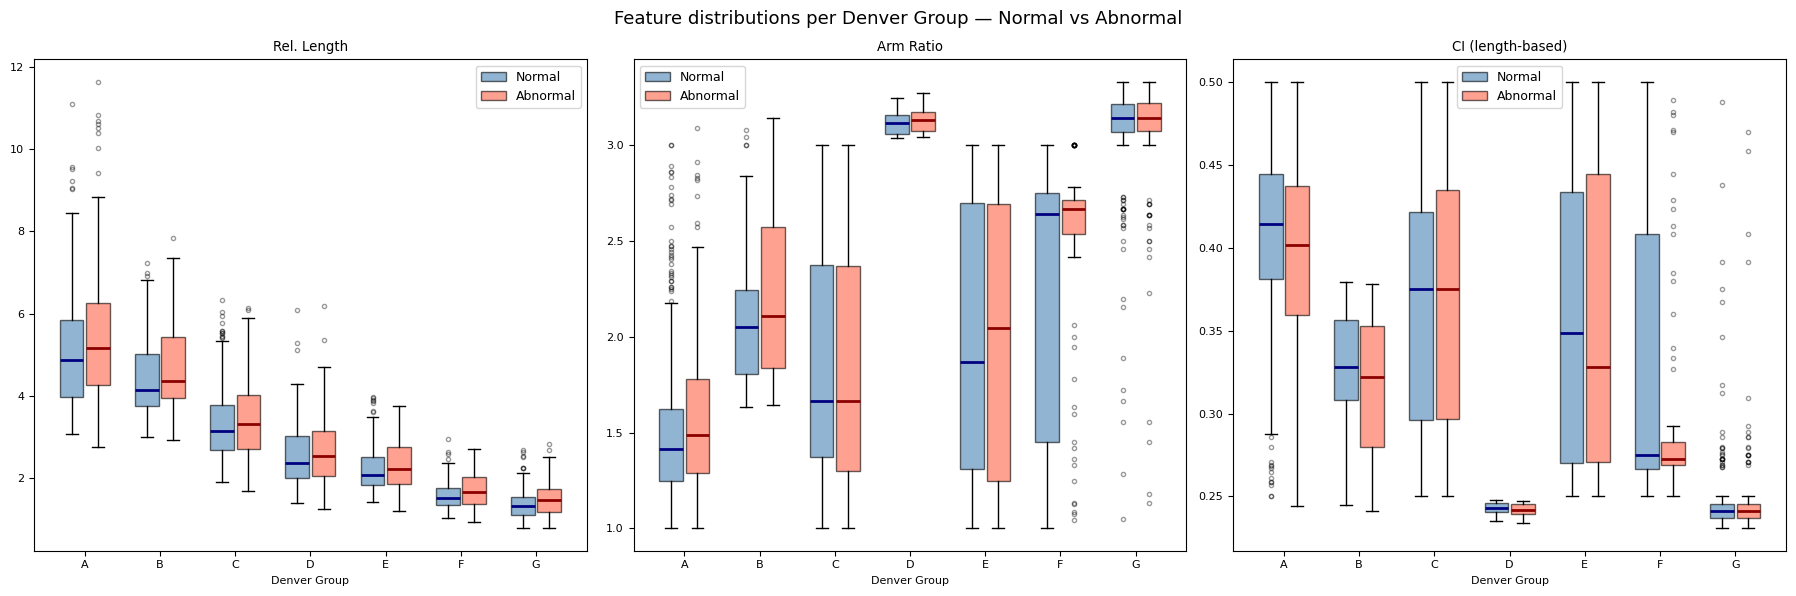

In [37]:
df_classified_normal['condition']   = 'Normal'
df_classified_abnormal['condition'] = 'Abnormal'
df_combined = pd.concat([df_classified_normal, df_classified_abnormal], ignore_index=True)
df_combined = df_combined[df_combined['denver_group'].isin(GROUPS)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (feat_name, col) in zip(axes, FEATURES.items()):
    data_normal   = [df_combined[(df_combined['denver_group'] == g) &
                                  (df_combined['condition'] == 'Normal')][col].dropna()
                     for g in GROUPS]
    data_abnormal = [df_combined[(df_combined['denver_group'] == g) &
                                  (df_combined['condition'] == 'Abnormal')][col].dropna()
                     for g in GROUPS]

    x     = np.arange(len(GROUPS))
    width = 0.35

    bp1 = ax.boxplot(data_normal,   positions=x - width/2, widths=width*0.9,
                     patch_artist=True,
                     boxprops=dict(facecolor='steelblue', alpha=0.6),
                     medianprops=dict(color='navy', linewidth=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.4))
    bp2 = ax.boxplot(data_abnormal, positions=x + width/2, widths=width*0.9,
                     patch_artist=True,
                     boxprops=dict(facecolor='tomato', alpha=0.6),
                     medianprops=dict(color='darkred', linewidth=2),
                     flierprops=dict(marker='o', markersize=3, alpha=0.4))

    ax.set_xticks(x)
    ax.set_xticklabels(GROUPS)
    ax.set_xlabel('Denver Group')
    ax.set_title(feat_name)
    ax.legend([bp1['boxes'][0], bp2['boxes'][0]], ['Normal', 'Abnormal'], fontsize=9)

plt.suptitle('Feature distributions per Denver Group — Normal vs Abnormal', fontsize=13)
plt.tight_layout()
plt.show()


### 3. ROC Curve — Can morphometric features distinguish Normal vs Abnormal?

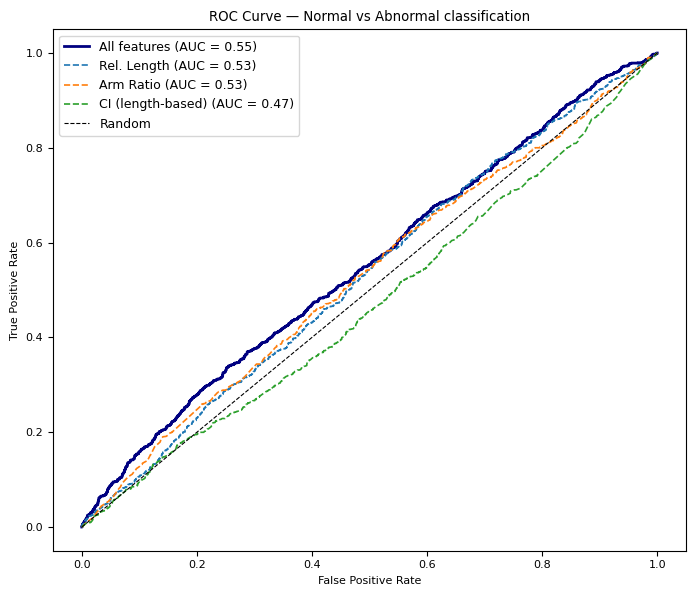


Logistic Regression AUC (all features): 0.552
AUC > 0.7 suggests the features carry discriminatory power.


In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, auc
from sklearn.pipeline import Pipeline

feature_cols = ['relative_length', 'arm_ratio', 'centromeric_index']

df_ml = df_combined[feature_cols + ['condition']].dropna()
X     = df_ml[feature_cols].values
y     = (df_ml['condition'] == 'Abnormal').astype(int).values

pipe  = Pipeline([('scaler', StandardScaler()),
                  ('clf',    LogisticRegression(max_iter=1000))])
pipe.fit(X, y)
y_prob = pipe.predict_proba(X)[:, 1]

fpr, tpr, _ = roc_curve(y, y_prob)
roc_auc     = auc(fpr, tpr)

# individual feature ROC curves
fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr, tpr, color='navy', lw=2,
        label=f'All features (AUC = {roc_auc:.2f})')

for feat_name, col in FEATURES.items():
    d  = df_combined[[col, 'condition']].dropna()
    xf = d[col].values
    yf = (d['condition'] == 'Abnormal').astype(int).values
    fpr_f, tpr_f, _ = roc_curve(yf, xf)
    ax.plot(fpr_f, tpr_f, lw=1.2, linestyle='--',
            label=f'{feat_name} (AUC = {auc(fpr_f, tpr_f):.2f})')

ax.plot([0, 1], [0, 1], 'k--', lw=0.8, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Normal vs Abnormal classification')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nLogistic Regression AUC (all features): {roc_auc:.3f}")
print("AUC > 0.7 suggests the features carry discriminatory power.")


[PosixPath('/Users/aning/Downloads/normal/103064.jpg'), PosixPath('/Users/aning/Downloads/normal/103095.jpg'), PosixPath('/Users/aning/Downloads/normal/103191.jpg'), PosixPath('/Users/aning/Downloads/normal/1032292.jpg'), PosixPath('/Users/aning/Downloads/normal/104143.jpg'), PosixPath('/Users/aning/Downloads/normal/104601.jpg'), PosixPath('/Users/aning/Downloads/normal/104632.jpg'), PosixPath('/Users/aning/Downloads/normal/104792.jpg'), PosixPath('/Users/aning/Downloads/normal/104801.jpg'), PosixPath('/Users/aning/Downloads/normal/104922.jpg'), PosixPath('/Users/aning/Downloads/normal/1050012.jpg'), PosixPath('/Users/aning/Downloads/normal/1050031.jpg'), PosixPath('/Users/aning/Downloads/normal/1050222_1.jpg'), PosixPath('/Users/aning/Downloads/normal/1050225_1.jpg'), PosixPath('/Users/aning/Downloads/normal/1050282.jpg'), PosixPath('/Users/aning/Downloads/normal/1050302_1.jpg'), PosixPath('/Users/aning/Downloads/normal/1050324.jpg'), PosixPath('/Users/aning/Downloads/normal/1050364.jpg'), PosixPath('/Users/aning/Downloads/normal/1050644.jpg'), PosixPath('/Users/aning/Downloads/normal/1050802.jpg'), PosixPath('/Users/aning/Downloads/normal/1051111.jpg'), PosixPath('/Users/aning/Downloads/normal/1051281.jpg'), PosixPath('/Users/aning/Downloads/normal/1052011.jpg'), PosixPath('/Users/aning/Downloads/normal/1052022.jpg'), PosixPath('/Users/aning/Downloads/normal/105203.jpg'), PosixPath('/Users/aning/Downloads/normal/1052054.jpg'), PosixPath('/Users/aning/Downloads/normal/1052112.jpg'), PosixPath('/Users/aning/Downloads/normal/1052123.jpg'), PosixPath('/Users/aning/Downloads/normal/1052262.jpg'), PosixPath('/Users/aning/Downloads/normal/1052402.jpg'), PosixPath('/Users/aning/Downloads/normal/1052622.jpg'), PosixPath('/Users/aning/Downloads/normal/1052661.jpg'), PosixPath('/Users/aning/Downloads/normal/1052712.jpg'), PosixPath('/Users/aning/Downloads/normal/1052721.jpg'), PosixPath('/Users/aning/Downloads/normal/1053543.jpg'), PosixPath('/Users/aning/Downloads/normal/1053591.jpg'), PosixPath('/Users/aning/Downloads/normal/1053771.jpg'), PosixPath('/Users/aning/Downloads/normal/1054022.jpg'), PosixPath('/Users/aning/Downloads/normal/1054081.jpg'), PosixPath('/Users/aning/Downloads/normal/1054311.jpg'), PosixPath('/Users/aning/Downloads/normal/1054452.jpg'), PosixPath('/Users/aning/Downloads/normal/1054791.jpg'), PosixPath('/Users/aning/Downloads/normal/1054831.jpg'), PosixPath('/Users/aning/Downloads/normal/1054883.jpg'), PosixPath('/Users/aning/Downloads/normal/1055302.jpg'), PosixPath('/Users/aning/Downloads/normal/1055391.jpg'), PosixPath('/Users/aning/Downloads/normal/1055512.jpg'), PosixPath('/Users/aning/Downloads/normal/1055634.jpg'), PosixPath('/Users/aning/Downloads/normal/1055662.jpg'), PosixPath('/Users/aning/Downloads/normal/1055753.jpg'), PosixPath('/Users/aning/Downloads/normal/1055932.jpg'), PosixPath('/Users/aning/Downloads/normal/1056334.jpg')]
[PosixPath('/Users/aning/Downloads/abnormal/103081.jpg'), PosixPath('/Users/aning/Downloads/abnormal/103092.jpg'), PosixPath('/Users/aning/Downloads/abnormal/103131.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1050431.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1050433.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1050434.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1050842.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1051013.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1051014.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1051261.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1051262.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1052521.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1052522.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1052523.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1052821.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1053271.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1053272.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1053273.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1053274.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1054071.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1054072.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1054073.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1055253.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1055742.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1055911.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1055912.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1055913.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1055914.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1056252.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1091253.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1091344.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1091345.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1091346.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1091421.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1091431.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1091521.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1091714.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101021.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101022.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101023.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101024.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101025.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101131.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101133.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101134.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101135.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101136.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101141.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101142.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101143.jpg'), PosixPath('/Users/aning/Downloads/abnormal/1101253.jpg')]